# Meet the SQL agent (and what it costs)

Before the RL notebook ([sql_agent_rl_loop.ipynb](sql_agent_rl_loop.ipynb)) *trains* a text-to-SQL agent, this notebook just *runs* one -- inference only, no training. An LLM is given three tools over the BIRD SQLite databases and asked a question; we watch it work, measure what each run costs, and score how correct it is.

We run the **same question across several models** (Fireworks and OpenAI) and report **input tokens, output tokens, cached tokens, and the dollar cost** per model, then grade each model on a small batch of questions with a **0-1 correctness score**.

## 1. Setup

```bash
pip install openai langchain-chroma langchain-fireworks chromadb
export FIREWORKS_API_KEY=fw_...
export OPENAI_API_KEY=sk-...      # optional: include OpenAI GPT-5.6 models
```

Fireworks and OpenAI both expose an OpenAI-compatible chat/completions API that reports `usage.prompt_tokens_details.cached_tokens`, so one agent loop prices both providers. Any model whose key is missing is simply skipped.

Run this notebook from `training/case-studies/agentic_rl_text2sql/` so it can read the `dev_databases/` (BIRD SQLite files) and `chromadb_text2sql/` (evidence store) already in this folder. If they're missing, build them with `python prepare_data.py`.

In [10]:
import json
import os
import sqlite3
from pathlib import Path

from openai import OpenAI

try:
    from dotenv import load_dotenv

    load_dotenv()
except ImportError:
    pass

HERE = next((p for p in [Path.cwd(), Path.cwd() / "training/case-studies/agentic_rl_text2sql"]
             if (p / "dev_databases").exists()), Path.cwd())
DB_ROOT = HERE / "dev_databases"
CHROMA_DIR = HERE / "chromadb_text2sql"
CHROMA_COLLECTION = "sql_examples"
EMBED_MODEL = "nomic-ai/nomic-embed-text-v1.5"

FIREWORKS_API_KEY = os.environ.get("FIREWORKS_API_KEY", "")
OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY", "")
assert FIREWORKS_API_KEY, "set FIREWORKS_API_KEY (export it or put it in a .env)"
assert DB_ROOT.exists(), f"dev_databases/ not found under {HERE} -- run prepare_data.py first"

FW_BASE = "https://api.fireworks.ai/inference/v1"
OPENAI_BASE = "https://api.openai.com/v1"

# Each model is a provider config: which endpoint + key to use, the API model id, a short
# label, and USD prices per 1M tokens. Both Fireworks and OpenAI expose the same
# OpenAI-compatible chat/completions + `usage.prompt_tokens_details.cached_tokens`, so one
# code path (run_agent) covers both -- we just point a client at the right base_url/key.
# `extra_args` are merged into the create() call (e.g. GPT-5.6 are hybrid reasoning models
# that reject function tools unless reasoning is disabled with reasoning_effort="none").
#
# PRICES ARE PLACEHOLDERS -- verify current rates (Fireworks: docs pricing tiers; OpenAI:
# platform.openai.com/pricing). `cached_input` is the discounted rate for prompt tokens
# served from cache (OpenAI caches automatically for long prompts; Fireworks via KV cache).
MODELS = [
    {"name": "deepseek-v4-flash", "provider": "fireworks", "model": "accounts/fireworks/models/deepseek-v4-flash-0731",
     "base_url": FW_BASE, "api_key": FIREWORKS_API_KEY,
     "prices": {"input": 0.14, "output": 0.28, "cached_input": 0.028}},
    {"name": "kimi-k3", "provider": "fireworks", "model": "accounts/fireworks/models/kimi-k3",
     "base_url": FW_BASE, "api_key": FIREWORKS_API_KEY,
     "prices": {"input": 3.00, "output": 15.00, "cached_input": 0.30}},
    {"name": "glm-5.2", "provider": "fireworks", "model": "accounts/fireworks/models/glm-5p2",
     "base_url": FW_BASE, "api_key": FIREWORKS_API_KEY,
     "prices": {"input": 1.40, "output": 4.40, "cached_input": 0.14}},
    # Closed models via their own OpenAI-compatible endpoints -- same client interface,
    # separate keys. Any entry whose key is unset is skipped. GPT-5.6 are hybrid reasoning
    # models; in /v1/chat/completions they reject function tools unless reasoning is turned
    # off, so we pass reasoning_effort="none". Prices from the model pages (cached_input
    # approximated at ~10% of input -- verify current rates).
    {"name": "gpt-5.6-sol (OpenAI)", "provider": "openai", "model": "gpt-5.6-sol",
     "base_url": OPENAI_BASE, "api_key": OPENAI_API_KEY,
     "extra_args": {"reasoning_effort": "none"},
     "prices": {"input": 5.00, "output": 30.00, "cached_input": 0.50}},
    {"name": "gpt-5.6-terra (OpenAI)", "provider": "openai", "model": "gpt-5.6-terra",
     "base_url": OPENAI_BASE, "api_key": OPENAI_API_KEY,
     "extra_args": {"reasoning_effort": "none"},
     "prices": {"input": 2.00, "output": 12.00, "cached_input": 0.20}},
    {"name": "gpt-5.6-luna (OpenAI)", "provider": "openai", "model": "gpt-5.6-luna",
     "base_url": OPENAI_BASE, "api_key": OPENAI_API_KEY,
     "extra_args": {"reasoning_effort": "none"},
     "prices": {"input": 0.20, "output": 1.20, "cached_input": 0.02}},
]

print(f"comparing {len(MODELS)} models: {', '.join(m['name'] for m in MODELS)}")

comparing 6 models: deepseek-v4-flash, kimi-k3, glm-5.2, gpt-5.6-sol (OpenAI), gpt-5.6-terra (OpenAI), gpt-5.6-luna (OpenAI)


## 2. The tools

Three tools, defined inline. `TOOL_SPECS` is the OpenAI function-tool schema the model sees; the functions below are what actually run when the model calls them. All return a plain string the model reads back.

- `get_database_schema` -- list a database's tables and columns (pure SQLite).
- `look_up_evidence` -- retrieve relevant SQL hints from the Chroma evidence store.
- `run_sql_against_database` -- execute a query and return the rows (pure SQLite).

In [11]:
# --- what the model sees: OpenAI function-tool schemas -------------------------
TOOL_SPECS = [
    {
        "type": "function",
        "function": {
            "name": "get_database_schema",
            "description": "Get the schema (tables, columns) for a specific database. Call this FIRST.",
            "parameters": {
                "type": "object",
                "properties": {
                    "database_id": {"type": "string", "description": "The database identifier, e.g. 'formula_1'."},
                },
                "required": ["database_id"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "look_up_evidence",
            "description": "Retrieve relevant SQL evidence/examples from a vector database. Call after the schema.",
            "parameters": {
                "type": "object",
                "properties": {
                    "query": {"type": "string", "description": "What to find relevant SQL examples for."},
                    "database_id": {"type": "string", "description": "Optional database ID filter."},
                    "k": {"type": "integer", "description": "Number of examples to retrieve (default 5)."},
                },
                "required": ["query"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "run_sql_against_database",
            "description": "Execute a SQL query against the specified database and return the rows.",
            "parameters": {
                "type": "object",
                "properties": {
                    "sql_query": {"type": "string", "description": "The SQL query to execute."},
                    "database_id": {"type": "string", "description": "The database identifier, e.g. 'formula_1'."},
                },
                "required": ["sql_query", "database_id"],
            },
        },
    },
]


def _db_path(database_id: str) -> Path:
    return DB_ROOT / database_id / f"{database_id}.sqlite"


# --- Chroma evidence store (opened once, closed over by look_up_evidence) ------
def _load_vector_store():
    import chromadb
    from chromadb.config import Settings
    from langchain_chroma import Chroma
    from langchain_fireworks import FireworksEmbeddings

    embeddings = FireworksEmbeddings(model=EMBED_MODEL)
    chroma_client = chromadb.PersistentClient(path=str(CHROMA_DIR), settings=Settings(anonymized_telemetry=False))
    return Chroma(
        client=chroma_client,
        collection_name=CHROMA_COLLECTION,
        embedding_function=embeddings,
        collection_metadata={"hnsw:space": "cosine"},
    )


vector_store = _load_vector_store() if CHROMA_DIR.exists() else None


# --- tool implementations ------------------------------------------------------
def get_database_schema(database_id: str) -> str:
    path = _db_path(database_id)
    if not path.exists():
        return f"Error: Database '{database_id}' not found at {path}"
    conn = sqlite3.connect(str(path))
    try:
        cur = conn.cursor()
        cur.execute("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name")
        tables = [r[0] for r in cur.fetchall() if not r[0].startswith("sqlite_")]
        lines = []
        for t in tables:
            cur.execute(f'PRAGMA table_info("{t}")')
            cols = [f"{c[1]} ({c[2]})" for c in cur.fetchall()]
            lines.append(f"Table {t}:\n  " + "\n  ".join(cols))
        body = "\n\n".join(lines) if lines else "(no tables)"
        return f"Database Schema for '{database_id}':\n\n{body}"
    finally:
        conn.close()


def look_up_evidence(query: str, database_id: str = "", k: int = 5) -> str:
    if vector_store is None:
        return "Evidence store not available (chromadb_text2sql/ missing)."
    try:
        kwargs = {"k": k}
        if database_id:
            kwargs["filter"] = {"db_id": database_id}
        results = vector_store.similarity_search_with_score(query, **kwargs)
        if not results:
            return f"No relevant evidence found for query: '{query}'"
        out = f"Found {len(results)} relevant examples:\n\n"
        for i, (doc, score) in enumerate(results, 1):
            out += f"Example {i} (similarity: {1 - score:.3f}):\n"
            out += f"Database: {doc.metadata.get('db_id')}\n"
            out += f"Evidence: {doc.page_content}\n"
            if doc.metadata.get("question"):
                out += f"Related Question: {doc.metadata['question']}\n"
            out += "-" * 50 + "\n"
        return out
    except Exception as e:  # noqa: BLE001
        return f"Error looking up evidence: {e}"


def run_sql_against_database(sql_query: str, database_id: str) -> str:
    path = _db_path(database_id)
    if not path.exists():
        return f"Error: Database '{database_id}' not found at {path}"
    conn = sqlite3.connect(str(path))
    try:
        cur = conn.cursor()
        cur.execute(sql_query)
        columns = [d[0] for d in cur.description] if cur.description else []
        rows = cur.fetchall()
    except Exception as e:  # noqa: BLE001
        return f"Error executing SQL query: {e}"
    finally:
        conn.close()
    if not rows:
        return "Query executed successfully but returned no results."
    out = f"Query executed successfully! Found {len(rows)} row(s):\n\n"
    if columns:
        header = " | ".join(columns)
        out += header + "\n" + "-" * len(header) + "\n"
    for r in rows[:10]:
        out += " | ".join("NULL" if c is None else str(c) for c in r) + "\n"
    if len(rows) > 10:
        out += f"\n... and {len(rows) - 10} more row(s)"
    return out


def execute_tool(name: str, arguments: dict) -> str:
    try:
        if name == "get_database_schema":
            return get_database_schema(str(arguments.get("database_id", "")))
        if name == "look_up_evidence":
            return look_up_evidence(
                str(arguments.get("query", "")),
                str(arguments.get("database_id", "") or ""),
                int(arguments.get("k", 5) or 5),
            )
        if name == "run_sql_against_database":
            return run_sql_against_database(
                str(arguments.get("sql_query", "")), str(arguments.get("database_id", ""))
            )
        return f"Error: unknown tool '{name}'"
    except Exception as e:  # noqa: BLE001
        return f"Error executing tool '{name}': {e}"


print(f"{len(TOOL_SPECS)} tools ready | evidence store: {'loaded' if vector_store else 'unavailable'}")

3 tools ready | evidence store: loaded


## 3. The agent loop

A minimal multi-turn loop: send the conversation + tool schemas to the model; if it returns `tool_calls`, run them, append the results, and loop; otherwise it has answered. We accumulate token usage across every turn -- `prompt_tokens`, `completion_tokens`, and `prompt_tokens_details.cached_tokens` (prompt tokens served from cache) -- so we can price the whole run.

In [12]:
SYSTEM_PROMPT = (
    "You are a text-to-SQL agent. Answer the user's question about a database by using the tools:\n"
    "1. FIRST call get_database_schema for the target database.\n"
    "2. THEN call look_up_evidence for relevant SQL hints.\n"
    "3. THEN write and run_sql_against_database to get the answer.\n"
    "Return exactly the rows/columns the question asks for, then give a short final answer."
)


def run_agent(cfg: dict, question: str, max_turns: int = 6) -> dict:
    """Run the multi-turn tool loop for one model config + question. Returns final text + usage.

    `cfg` selects the endpoint/key/model (Fireworks or OpenAI); both speak the same
    OpenAI-compatible chat/completions API, so this one loop covers both providers.
    """
    client = OpenAI(base_url=cfg["base_url"], api_key=cfg["api_key"])
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": question},
    ]
    prompt_tokens = completion_tokens = cached_tokens = 0
    trajectory = []  # (kind, text) for pretty-printing
    final_text = ""
    turns = 0  # model calls in this run (one per loop iteration)
    last_sql = last_db = None  # last run_sql_against_database call, for scoring

    for _ in range(max_turns):
        turns += 1
        resp = client.chat.completions.create(
            model=cfg["model"], messages=messages, tools=TOOL_SPECS, temperature=0,
            **cfg.get("extra_args", {}),
        )
        usage = resp.usage
        prompt_tokens += usage.prompt_tokens
        completion_tokens += usage.completion_tokens
        details = getattr(usage, "prompt_tokens_details", None)
        cached_tokens += getattr(details, "cached_tokens", 0) or 0

        msg = resp.choices[0].message
        messages.append(msg.model_dump(exclude_none=True))  # echo assistant turn back

        if not msg.tool_calls:
            final_text = msg.content or ""
            break

        for tc in msg.tool_calls:
            try:
                args = json.loads(tc.function.arguments or "{}")
            except json.JSONDecodeError:
                args = {}
            trajectory.append(("call", f"{tc.function.name}({json.dumps(args)})"))
            if tc.function.name == "run_sql_against_database":
                last_sql = args.get("sql_query")
                last_db = args.get("database_id")
            result = execute_tool(tc.function.name, args)
            trajectory.append(("result", result))
            messages.append({"role": "tool", "tool_call_id": tc.id, "content": result})

    return {
        "name": cfg["name"],
        "final_text": final_text,
        "last_sql": last_sql,
        "last_db": last_db,
        "turns": turns,
        "prompt_tokens": prompt_tokens,
        "completion_tokens": completion_tokens,
        "cached_tokens": cached_tokens,
        "trajectory": trajectory,
    }


def run_cost(res: dict, cfg: dict) -> float:
    """USD cost of a run from the config's prices (uncached input + cached input + output)."""
    p = cfg["prices"]
    uncached_in = max(res["prompt_tokens"] - res["cached_tokens"], 0)
    return (
        uncached_in * p["input"]
        + res["cached_tokens"] * p["cached_input"]
        + res["completion_tokens"] * p["output"]
    ) / 1_000_000

print("run_agent + run_cost defined")

run_agent + run_cost defined


## 4. Run one question across models + compare cost

Same question, same tools, one run per model. We show the full trajectory for the first model (so the tool loop is visible), then a table of tokens in / out / cached and the run's dollar cost per model. Each model is run independently, so one that can't tool-call is just skipped.

In [13]:
QUESTION = (
    "In the financial database, among the accounts with an approved loan in 1997, "
    "which account has the lowest approved amount? Return the account id."
)

results = []
for cfg in MODELS:
    if not cfg["api_key"]:
        print(f"skipped {cfg['name']}: no API key set for provider '{cfg['provider']}'")
        continue
    try:
        res = run_agent(cfg, QUESTION)
        res["cost"] = run_cost(res, cfg)
        results.append(res)
        print(f"ran {cfg['name']}: {res['turns']} turns / {res['prompt_tokens']} in / "
              f"{res['completion_tokens']} out / {res['cached_tokens']} cached")
    except Exception as e:  # noqa: BLE001
        print(f"skipped {cfg['name']}: {type(e).__name__}: {str(e)[:120]}")

# Full trajectory for the first successful model, so the tool loop is visible.
if results:
    r0 = results[0]
    print(f"\n===== trajectory: {r0['name']} =====")
    for kind, text in r0["trajectory"]:
        print(f"  -> {text}" if kind == "call" else f"  <- {text.strip()[:200]}")
    print(f"  answer: {r0['final_text'].strip()[:400]}")

# Comparison table.
print(f"\n{'model':24} {'turns':>6} {'in':>8} {'out':>8} {'cached':>8} {'cost $':>10}")
for r in results:
    print(f"{r['name']:24} {r['turns']:>6} {r['prompt_tokens']:>8} {r['completion_tokens']:>8} "
          f"{r['cached_tokens']:>8} {r['cost']:>10.5f}")

ran deepseek-v4-flash: 6 turns / 11053 in / 1749 out / 8109 cached
ran kimi-k3: 5 turns / 7752 in / 1173 out / 3072 cached
ran glm-5.2: 6 turns / 7455 in / 584 out / 5681 cached
ran gpt-5.6-sol (OpenAI): 4 turns / 3583 in / 162 out / 2334 cached
ran gpt-5.6-terra (OpenAI): 4 turns / 3526 in / 152 out / 2278 cached
ran gpt-5.6-luna (OpenAI): 4 turns / 3548 in / 172 out / 1152 cached

===== trajectory: deepseek-v4-flash =====
  -> get_database_schema({"database_id": "financial"})
  <- Database Schema for 'financial':

Table account:
  account_id (INTEGER)
  district_id (INTEGER)
  frequency (TEXT)
  date (DATE)

Table card:
  card_id (INTEGER)
  disp_id (INTEGER)
  type (TEXT)
  is
  -> look_up_evidence({"query": "approved loan in 1997 lowest amount account id", "database_id": "financial"})
  <- Found 5 relevant examples:

Example 1 (similarity: 0.583):
Database: financial
Evidence: After 1996 means date > = '1997-01-01
Related Question: List all the clients' IDs whose junior credit card

In [20]:

# Full trajectory for the first successful model, so the tool loop is visible.
if results:
    r0 = results[1]
    print(f"\n===== trajectory: {r0['name']} =====")
    for kind, text in r0["trajectory"]:
        print(f"  -> {text}" if kind == "call" else f"  <- {text.strip()[:200]}")
    print(f"  answer: {r0['final_text'].strip()}")

# Comparison table.
print(f"\n{'model':24} {'turns':>6} {'in':>8} {'out':>8} {'cached':>8} {'cost $':>10}")
for r in results:
    print(f"{r['name']:24} {r['turns']:>6} {r['prompt_tokens']:>8} {r['completion_tokens']:>8} "
          f"{r['cached_tokens']:>8} {r['cost']:>10.5f}")


===== trajectory: kimi-k3 =====
  -> get_database_schema({"database_id": "financial"})
  <- Database Schema for 'financial':

Table account:
  account_id (INTEGER)
  district_id (INTEGER)
  frequency (TEXT)
  date (DATE)

Table card:
  card_id (INTEGER)
  disp_id (INTEGER)
  type (TEXT)
  is
  -> look_up_evidence({"database_id": "financial", "query": "loans approved in 1997 with lowest amount, loan status values"})
  <- Found 5 relevant examples:

Example 1 (similarity: 0.641):
Database: financial
Evidence: status = 'A' refers to loan contracts finished with no problems
Related Question: Which district has the most a
  -> run_sql_against_database({"database_id": "financial", "sql_query": "SELECT DISTINCT status FROM loan;"})
  <- Query executed successfully! Found 4 row(s):

status
------
A
B
D
C
  -> run_sql_against_database({"database_id": "financial", "sql_query": "SELECT account_id, loan_id, date, amount, status FROM loan WHERE strftime('%Y', date) = '1997' ORDER BY amount ASC LIM

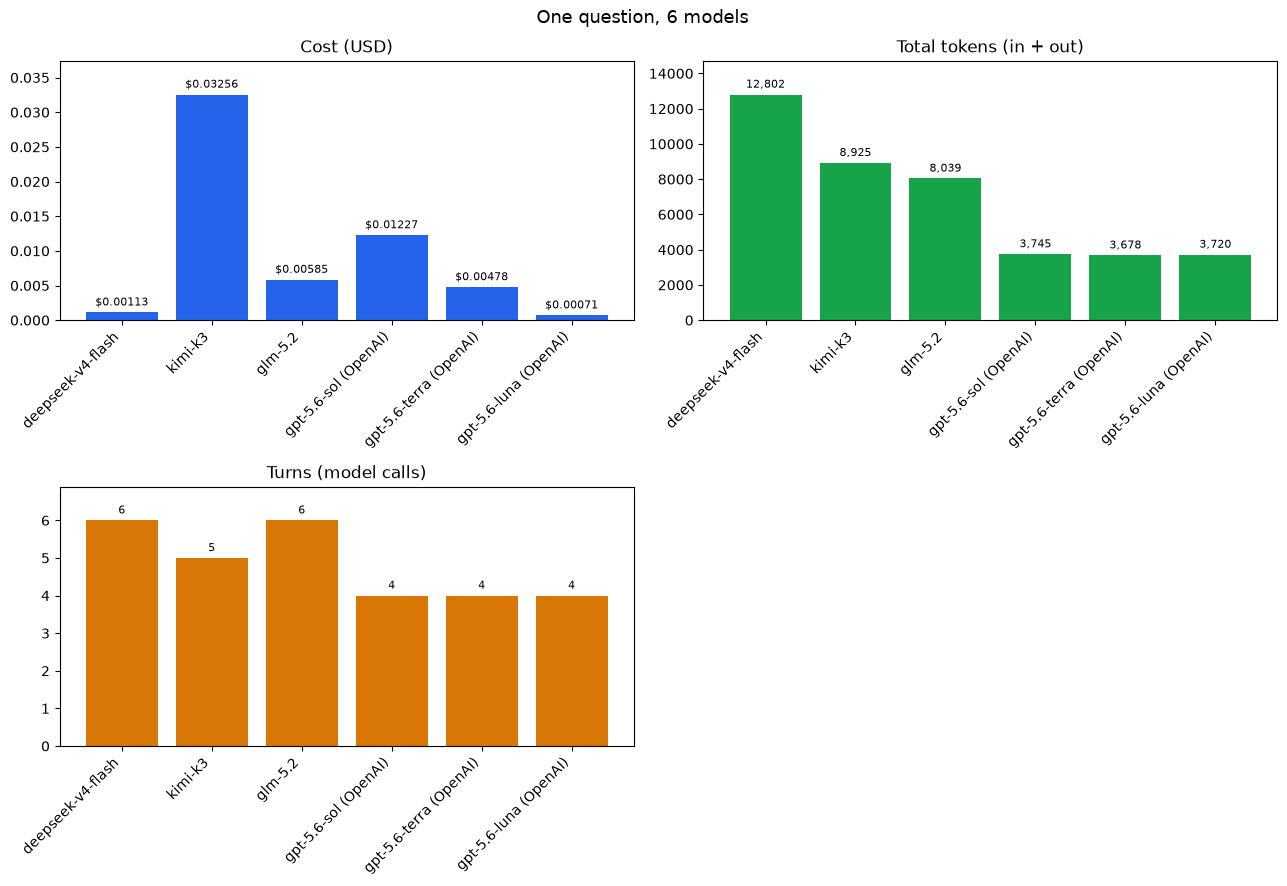

In [14]:
import matplotlib.pyplot as plt

# Side-by-side view of the same run across models: cost, total tokens, and turns.
names = [r["name"] for r in results]
costs = [r["cost"] for r in results]
tokens = [r["prompt_tokens"] + r["completion_tokens"] for r in results]
turns = [r["turns"] for r in results]

panels = [
    (costs, "Cost (USD)", "#2563eb", "${:.5f}"),
    (tokens, "Total tokens (in + out)", "#16a34a", "{:,}"),
    (turns, "Turns (model calls)", "#d97706", "{}"),
]
ncols = 2
nrows = -(-len(panels) // ncols)  # ceil
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4.5 * nrows))
axes = axes.flatten()
for ax, (vals, title, color, fmt) in zip(axes, panels):
    bars = ax.bar(names, vals, color=color)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=45)
    for lbl in ax.get_xticklabels():
        lbl.set_ha("right")
    ax.bar_label(bars, labels=[fmt.format(v) for v in vals], padding=3, fontsize=8)
    ax.margins(y=0.15)
for ax in axes[len(panels):]:  # hide any unused slots
    ax.axis("off")

fig.suptitle(f"One question, {len(results)} models", fontsize=13)
fig.tight_layout()
plt.show()


## 5. Score the answers (0-1)

A quick correctness check across **all models**: run the first `N_EVAL` `dev.json` questions through each model, then compare the agent's **last executed SQL result set** against the **gold query's** result set. Score is order-insensitive multiset overlap — `1.0` for an exact match, Jaccard overlap for partial, `0.0` if the agent never ran SQL or it errored. This is the same signal the RL notebook rewards, computed here just to see where the base model stands.

We report each model's **running mean** at `N = 1, 3, 5, 10` so you can see how noisy a small eval is — a single question tells you almost nothing; the average steadies as N grows.

In [15]:
from collections import Counter

N_CHECKPOINTS = [1, 3, 5, 10]  # report the running mean at these sample sizes
N_EVAL = max(N_CHECKPOINTS)  # score this many dev.json questions once, then slice


def _sql_rows(database_id: str, sql: str):
    """Execute SQL and return rows as a list of tuples, or None on error."""
    if not sql:
        return None
    path = _db_path(database_id)
    if not path.exists():
        return None
    conn = sqlite3.connect(str(path))
    try:
        cur = conn.cursor()
        cur.execute(sql)
        return cur.fetchall()
    except Exception:  # noqa: BLE001
        return None
    finally:
        conn.close()


def _multiset(rows) -> Counter:
    """Order-insensitive multiset of normalized cell tuples (numbers rounded to 6dp)."""
    c: Counter = Counter()
    for row in rows or []:
        cells = row if isinstance(row, (list, tuple)) else [row]
        norm = []
        for x in cells:
            if x is None:
                norm.append("NULL")
            elif isinstance(x, bool):
                norm.append(str(x))
            elif isinstance(x, (int, float)):
                norm.append(f"{round(float(x), 6):g}")
            else:
                norm.append(str(x).strip())
        c[tuple(norm)] += 1
    return c


def score_result(pred_rows, gold_rows) -> float:
    """1.0 exact match, else Jaccard overlap of the two result-set multisets."""
    if pred_rows is None:
        return 0.0
    pred, gold = _multiset(pred_rows), _multiset(gold_rows)
    if not pred and not gold:
        return 1.0
    if pred == gold:
        return 1.0
    inter = sum((pred & gold).values())
    union = sum((pred | gold).values())
    return inter / union if union else 0.0


import time

with open(HERE / "dev.json") as f:
    dev = json.load(f)[:N_EVAL]

# Precompute gold result sets once (same across all models).
gold_by_q = [_sql_rows(ex["db_id"], ex["SQL"]) for ex in dev]

active = [c for c in MODELS if c["api_key"]]
for c in MODELS:
    if not c["api_key"]:
        print(f"skipped {c['name']}: no API key set for provider '{c['provider']}'")
print(f"scoring {len(active)} models x {len(dev)} questions "
      f"= {len(active) * len(dev)} agent runs\n", flush=True)

# Score every model with an API key over the same N questions, logging each run so
# progress is visible (a full sweep is many multi-turn runs and can take minutes).
per_model_scores = {}
per_model_cost = {}  # total USD spent per model across all N questions
for mi, cfg in enumerate(active, 1):
    scores = []
    model_cost = 0.0
    for qi, (ex, gold_rows) in enumerate(zip(dev, gold_by_q), 1):
        q = f"In the {ex['db_id']} database, {ex['question']}"
        t0 = time.time()
        try:
            res = run_agent(cfg, q)
            cost = run_cost(res, cfg)
            model_cost += cost
            pred_rows = _sql_rows(res["last_db"] or ex["db_id"], res["last_sql"])
            s = score_result(pred_rows, gold_rows)
            scores.append(s)
            print(f"  [{mi}/{len(active)} {cfg['name']:22}] q{qi}/{len(dev)} "
                  f"score={s:.2f} (${cost:.5f}, {res['turns']} turns, {time.time() - t0:.1f}s)",
                  flush=True)
        except Exception as e:  # noqa: BLE001
            scores.append(0.0)
            print(f"  [{mi}/{len(active)} {cfg['name']:22}] q{qi}/{len(dev)} "
                  f"FAILED {type(e).__name__}: {str(e)[:60]} ({time.time() - t0:.1f}s)", flush=True)
    per_model_scores[cfg["name"]] = scores
    per_model_cost[cfg["name"]] = model_cost
    print(f"  -> done {cfg['name']}: mean {sum(scores) / len(scores):.3f}, "
          f"total ${model_cost:.5f}\n", flush=True)

# Mean score at each checkpoint N, one row per model.
header = "model".ljust(24) + "".join(f"N={n:<8}" for n in N_CHECKPOINTS)
print(f"\n{header}")
for name, scores in per_model_scores.items():
    row = name.ljust(24)
    for n in N_CHECKPOINTS:
        row += (f"{sum(scores[:n]) / n:.3f}".ljust(10)) if n <= len(scores) else "-".ljust(10)
    print(row)


scoring 6 models x 10 questions = 60 agent runs

  [1/6 deepseek-v4-flash     ] q1/10 score=0.00 ($0.00082, 4 turns, 31.1s)
  [1/6 deepseek-v4-flash     ] q2/10 score=0.00 ($0.00123, 5 turns, 37.3s)
  [1/6 deepseek-v4-flash     ] q3/10 score=0.83 ($0.00053, 3 turns, 8.3s)
  [1/6 deepseek-v4-flash     ] q4/10 score=1.00 ($0.00069, 4 turns, 34.3s)
  [1/6 deepseek-v4-flash     ] q5/10 score=0.77 ($0.00136, 6 turns, 46.4s)
  [1/6 deepseek-v4-flash     ] q6/10 score=0.00 ($0.00111, 6 turns, 99.0s)
  [1/6 deepseek-v4-flash     ] q7/10 score=0.00 ($0.00073, 3 turns, 38.2s)
  [1/6 deepseek-v4-flash     ] q8/10 score=0.00 ($0.00107, 5 turns, 48.6s)
  [1/6 deepseek-v4-flash     ] q9/10 score=0.00 ($0.00094, 5 turns, 78.1s)
  [1/6 deepseek-v4-flash     ] q10/10 score=0.00 ($0.00190, 5 turns, 49.2s)
  -> done deepseek-v4-flash: mean 0.261, total $0.01040

  [2/6 kimi-k3               ] q1/10 score=1.00 ($0.02414, 4 turns, 15.1s)
  [2/6 kimi-k3               ] q2/10 score=1.00 ($0.03577, 6 turns, 6

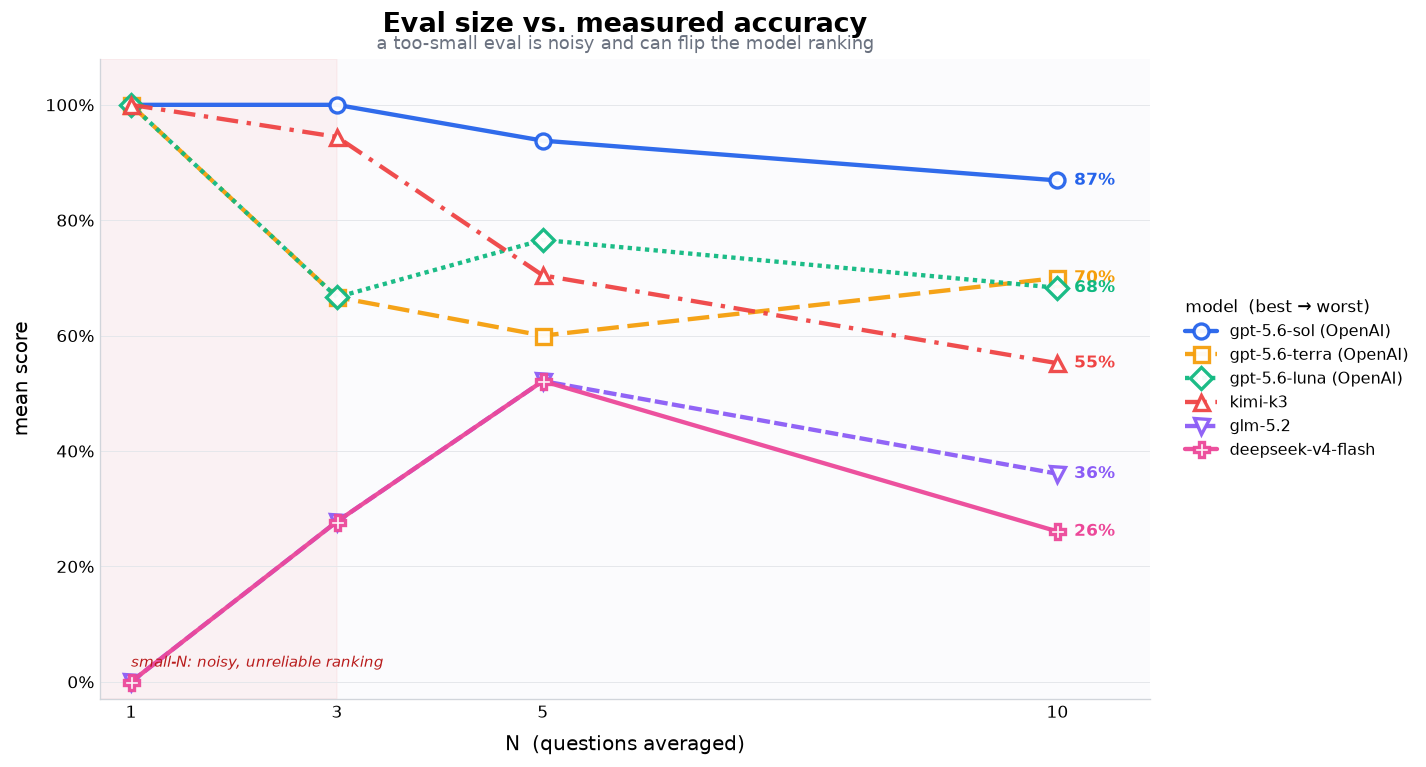

In [16]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Same numbers as the table, drawn so the eval-size effect is obvious: each line is a
# model, each x is a checkpoint N. Where lines cross/reorder between N=1 and N=10 is
# exactly where a too-small eval would have misled you about which model is "best".
# Distinct color + marker + linestyle per model so overlapping lines stay readable.
plt.rcParams.update({"font.family": "DejaVu Sans", "axes.axisbelow": True})

palette = ["#2563eb", "#f59e0b", "#10b981", "#ef4444", "#8b5cf6",
           "#ec4899", "#14b8a6", "#64748b"]
markers = ["o", "s", "D", "^", "v", "P", "X", "*"]
dashes = [(None, None), (5, 2), (1, 1), (5, 2, 1, 2), (3, 1, 3, 1)]

xs_full = list(N_CHECKPOINTS)
ranked = sorted(per_model_scores.items(),
                key=lambda kv: sum(kv[1]) / len(kv[1]), reverse=True)

fig, ax = plt.subplots(figsize=(12, 6.5), dpi=120)
fig.patch.set_facecolor("white")
ax.set_facecolor("#fbfbfd")

for i, (name, scores) in enumerate(ranked):
    xs = [n for n in xs_full if n <= len(scores)]
    ys = [sum(scores[:n]) / n for n in xs]
    color = palette[i % len(palette)]
    ax.plot(xs, ys, color=color, marker=markers[i % len(markers)], markersize=9,
            markerfacecolor="white", markeredgecolor=color, markeredgewidth=2,
            linewidth=2.6, dashes=dashes[i % len(dashes)], alpha=0.95,
            solid_capstyle="round", label=name, zorder=3)
    # Value label at the final point.
    ax.annotate(f"{ys[-1]:.0%}", (xs[-1], ys[-1]), textcoords="offset points",
                xytext=(10, 0), va="center", fontsize=10, fontweight="bold", color=color)

# Shade the "danger zone" of tiny evals to make the takeaway visual.
ax.axvspan(min(xs_full) - 0.3, 3, color="#ef4444", alpha=0.05, zorder=0)
ax.text(min(xs_full), 0.02, "small-N: noisy, unreliable ranking",
        fontsize=9, style="italic", color="#b91c1c", ha="left", va="bottom")

ax.set_xticks(xs_full)
ax.set_xlim(min(xs_full) - 0.3, max(xs_full) + 0.9)
ax.set_ylim(-0.03, 1.08)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
ax.set_xlabel("N  (questions averaged)", fontsize=12, labelpad=8)
ax.set_ylabel("mean score", fontsize=12, labelpad=8)
ax.set_title("Eval size vs. measured accuracy", fontsize=16, fontweight="bold", pad=16)
ax.text(0.5, 1.015, "a too-small eval is noisy and can flip the model ranking",
        transform=ax.transAxes, ha="center", fontsize=10.5, color="#6b7280")

ax.grid(True, axis="y", linestyle="-", linewidth=0.6, color="#e5e7eb")
ax.grid(False, axis="x")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):
    ax.spines[spine].set_color("#d1d5db")
ax.tick_params(length=0, labelsize=10)

leg = ax.legend(title="model  (best \u2192 worst)", title_fontsize=10, fontsize=9.5,
                loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
leg._legend_box.align = "left"

fig.tight_layout()
plt.show()


/var/folders/0h/c6c4v8153bz0v35w1mcvqvpw0000gn/T/ipykernel_47464/2048562940.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)
/var/folders/0h/c6c4v8153bz0v35w1mcvqvpw0000gn/T/ipykernel_47464/2048562940.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)


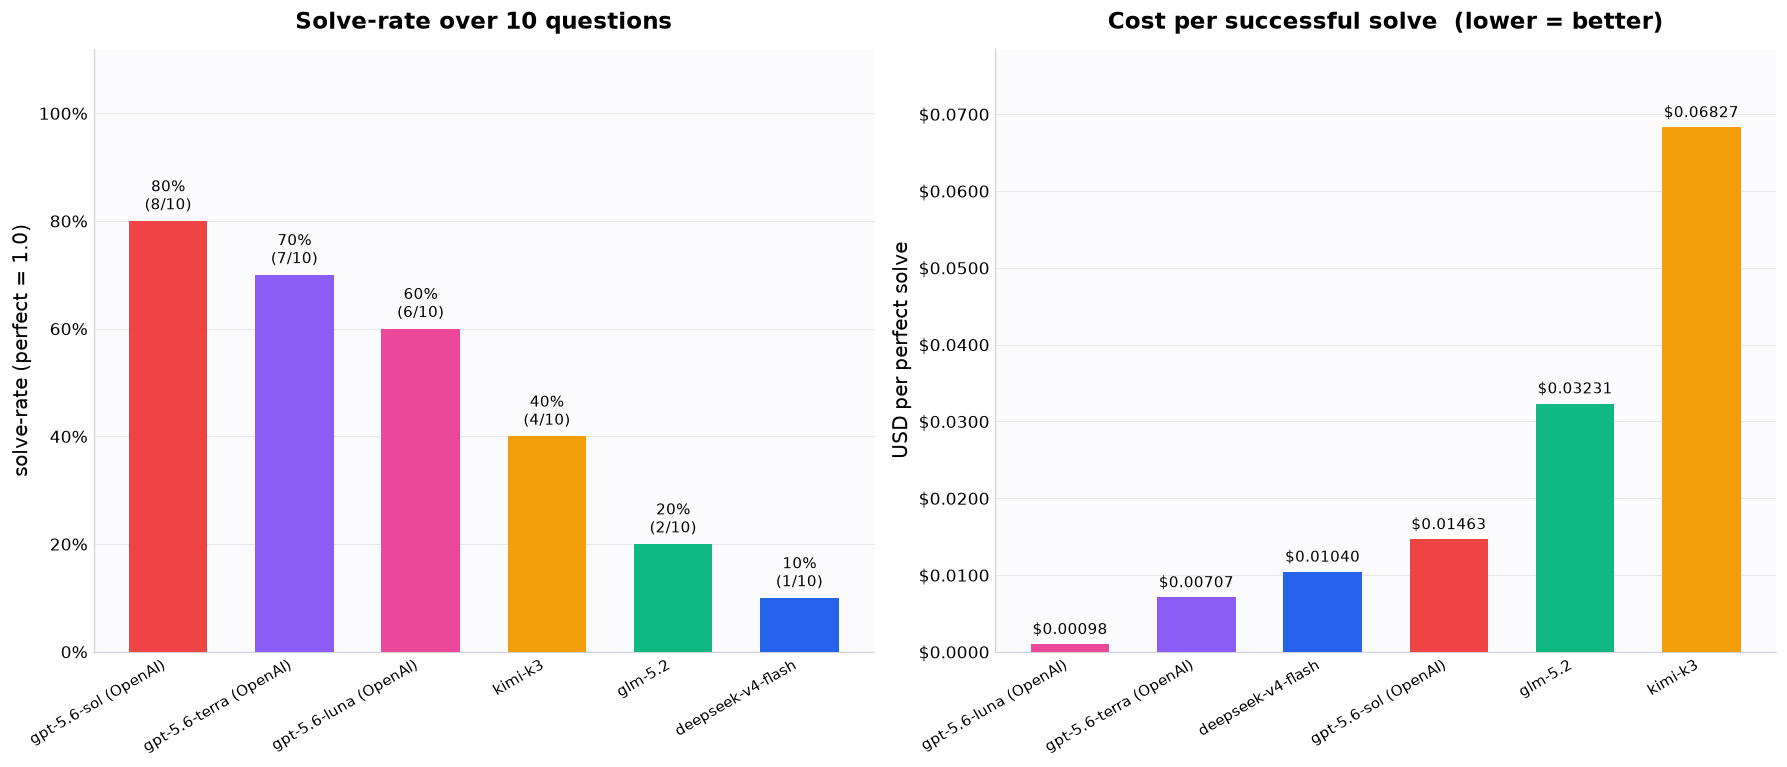

In [17]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, FuncFormatter

# Two views over the full N-question sweep:
#   (left)  solve-rate = fraction of questions with a PERFECT score (1.0).
#   (right) cost per successful solve = total spend / number of perfect solves
#           -- the metric that actually matters: dollars per task you can trust.
names = list(per_model_scores.keys())
solves = {n: sum(s == 1.0 for s in per_model_scores[n]) for n in names}
solve_rate = {n: solves[n] / len(per_model_scores[n]) for n in names}
cost_per_solve = {
    n: (per_model_cost[n] / solves[n]) if solves[n] else float("inf") for n in names
}

palette = ["#2563eb", "#f59e0b", "#10b981", "#ef4444", "#8b5cf6",
           "#ec4899", "#14b8a6", "#64748b"]


def _style(ax):
    ax.set_facecolor("#fbfbfd")
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    for sp in ("left", "bottom"):
        ax.spines[sp].set_color("#d1d5db")
    ax.grid(True, axis="y", linewidth=0.6, color="#e5e7eb")
    ax.tick_params(length=0)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.5), dpi=120)
fig.patch.set_facecolor("white")

# --- left: solve-rate, sorted best-first ---
order = sorted(names, key=lambda n: solve_rate[n], reverse=True)
vals = [solve_rate[n] for n in order]
colors = [palette[names.index(n) % len(palette)] for n in order]
bars = ax1.bar(order, vals, color=colors, width=0.62, zorder=3)
ax1.bar_label(bars, labels=[f"{v:.0%}\n({solves[n]}/{len(per_model_scores[n])})"
                            for n, v in zip(order, vals)], padding=4, fontsize=9)
ax1.set_ylim(0, 1.12)
ax1.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
ax1.set_ylabel("solve-rate (perfect = 1.0)", fontsize=12)
ax1.set_title(f"Solve-rate over {len(next(iter(per_model_scores.values())))} questions",
              fontsize=14, fontweight="bold", pad=12)
_style(ax1)

# --- right: cost per successful solve, cheapest-first (drop models with 0 solves) ---
solved = [n for n in names if solves[n] > 0]
order2 = sorted(solved, key=lambda n: cost_per_solve[n])
vals2 = [cost_per_solve[n] for n in order2]
colors2 = [palette[names.index(n) % len(palette)] for n in order2]
bars2 = ax2.bar(order2, vals2, color=colors2, width=0.62, zorder=3)
ax2.bar_label(bars2, labels=[f"${v:.5f}" for v in vals2], padding=4, fontsize=9)
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:.4f}"))
ax2.set_ylabel("USD per perfect solve", fontsize=12)
ax2.set_title("Cost per successful solve  (lower = better)",
              fontsize=14, fontweight="bold", pad=12)
ax2.margins(y=0.15)
_style(ax2)
if len(order2) < len(names):
    missed = [n for n in names if solves[n] == 0]
    ax2.text(0.5, -0.22, "excluded (0 perfect solves): " + ", ".join(missed),
             transform=ax2.transAxes, ha="center", fontsize=9, color="#b91c1c")

for ax in (ax1, ax2):
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)

fig.tight_layout()
plt.show()


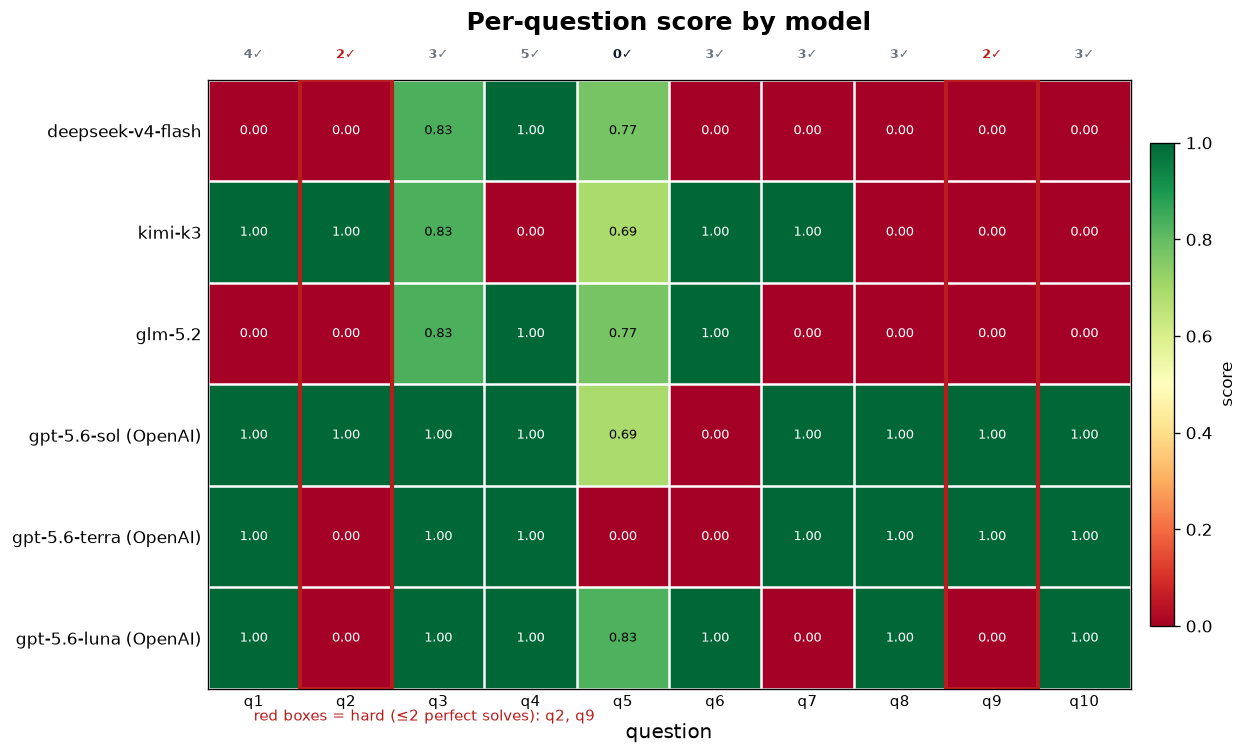

Hard questions (<= 2 models solved perfectly):
  q2 (california_schools): solved by kimi-k3, gpt-5.6-sol (OpenAI)
      Please list the lowest three eligible free rates for students aged 5-17 in continuation schools.
  q9 (california_schools): solved by gpt-5.6-sol (OpenAI), gpt-5.6-terra (OpenAI)
      What is the number of SAT test takers of the schools with the highest FRPM count for K-12 students?

Nobody solved: q5


In [18]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

# Per-question breakdown: rows = models, cols = questions, cell = score (0-1).
# Questions that only 1-2 models solved perfectly are the "hard" ones -- we box
# those columns so you can see exactly where models agree vs. where they don't.
HARD_MAX_SOLVERS = 2  # a question is "hard" if <= this many models scored a perfect 1.0

names = list(per_model_scores.keys())
n_q = len(next(iter(per_model_scores.values())))
M = np.array([per_model_scores[n] for n in names])  # shape (models, questions)

perfect = M >= 1.0
solvers_per_q = perfect.sum(axis=0)                  # how many models nailed each question
hard_cols = [j for j in range(n_q) if 0 < solvers_per_q[j] <= HARD_MAX_SOLVERS]
nobody = [j for j in range(n_q) if solvers_per_q[j] == 0]

fig, ax = plt.subplots(figsize=(max(9, 1.05 * n_q), 0.7 * len(names) + 2.2), dpi=120)
im = ax.imshow(M, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")

ax.set_xticks(range(n_q))
ax.set_xticklabels([f"q{i + 1}" for i in range(n_q)], fontsize=9)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=10)
ax.set_xlabel("question", fontsize=12, labelpad=8)
ax.set_title("Per-question score by model", fontsize=15, fontweight="bold", pad=30)

# Score in each cell.
for i in range(len(names)):
    for j in range(n_q):
        v = M[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                color="black" if 0.25 < v < 0.85 else "white")

# Solver count above each column + box the hard ones.
for j in range(n_q):
    k = int(solvers_per_q[j])
    color = "#b91c1c" if 0 < k <= HARD_MAX_SOLVERS else ("#6b7280" if k else "#111827")
    ax.text(j, -0.75, f"{k}\u2713", ha="center", va="center", fontsize=8,
            fontweight="bold", color=color)
for j in hard_cols:
    ax.add_patch(Rectangle((j - 0.5, -0.5), 1, len(names), fill=False,
                           edgecolor="#b91c1c", linewidth=2.5, zorder=5))

ax.set_xticks(np.arange(-0.5, n_q, 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(names), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.5)
ax.tick_params(which="minor", length=0)
ax.tick_params(which="major", length=0)

cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label("score", fontsize=10)

hard_label = ", ".join(f"q{j + 1}" for j in hard_cols) or "none"
ax.text(0, len(names) - 0.3,
        f"red boxes = hard (\u2264{HARD_MAX_SOLVERS} perfect solves): {hard_label}",
        transform=ax.transData, fontsize=9, color="#b91c1c", va="top")

fig.tight_layout()
plt.show()

# Text summary of the hard / unsolved questions with the actual prompt.
print(f"Hard questions (<= {HARD_MAX_SOLVERS} models solved perfectly):")
for j in hard_cols:
    winners = [names[i] for i in range(len(names)) if perfect[i, j]]
    print(f"  q{j + 1} ({dev[j]['db_id']}): solved by {', '.join(winners)}")
    print(f"      {dev[j]['question'][:100]}")
if nobody:
    print(f"\nNobody solved: {', '.join(f'q{j + 1}' for j in nobody)}")


## Recap

That's the whole agent: an LLM, three tools over a SQLite database, and a loop. No training, just inference, plus a per-model view of tokens, cost, and a basic correctness score.

The next notebook, [sql_agent_rl_loop.ipynb](sql_agent_rl_loop.ipynb), adds a **reward** (does the final query's result set match gold?) and runs **serverless RL** so a model gets better at exactly this loop.

Notes:
- Token counts and cost are for a **single question's multi-turn run** and vary with the question, the schema size, and how many turns the model takes -- this is an illustration, not a benchmark.
- `PRICES` are placeholders: confirm current per-model serverless-inference rates on the Fireworks pricing docs before quoting numbers.
- `cached` tokens are prompt tokens served from Fireworks' KV cache (billed at the discounted `cached_input` rate); they grow when a model re-reads the same accumulating context across turns.
- The 0-1 score is result-set overlap vs the gold SQL, the same signal the RL notebook optimizes.